# Clustering

"If intelligence was a cake, unsupervised learning would be the cake, supervised learning would be the icing on the cake, and reinforcement learning would be the cherry on the cake" - Yann LeCun

Análisis de Agrupamientos: Proceso de particionamiento de un conjunto de datos (u observaciones) en subconjuntos. Cada subconjunto es un grupo o cluster.

* Los datos en un mismo cluster deben ser similares entre sí.
* Los datos de diferentes clusters deben ser diferentes entre sí.

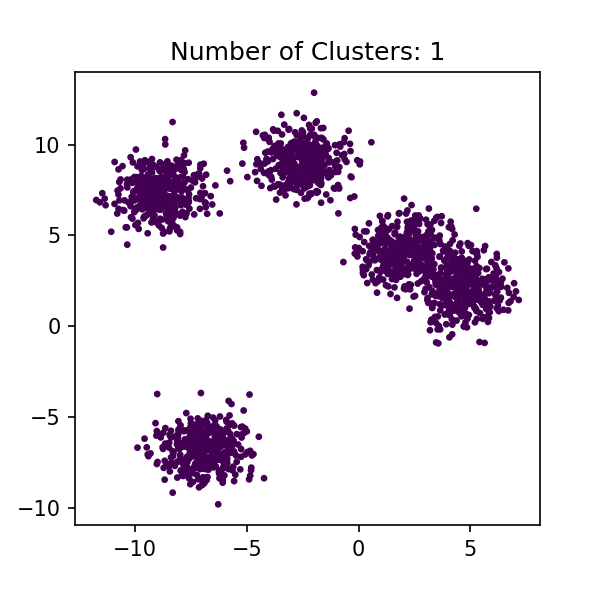

## K-Means

* Método que permite crear __clusters__ a partir de __datos numéricos__. El input del sistema son las mediciones numéricas de interés y los outputs son:
    * los centroides de los __clusters__ resultantes
    * la asignación de cada dato a un __cluster__ determinado.

* El __centroide__ es el punto que se encuentra en el centro de un __cluster__, (es la media de las coordenadas de todos los puntos de ese __cluster__).

* El número de centroides `k` es definido según convenga, para definir la distancia entre puntos y entre centroides se suele utilizar la distancia euclídea.

* La __inercia__ del modelo es la métrica de rendimiento usada para saber donde colocar mejor los centroides, la inercia del modelo es la
distancia media cuadrática entre cada observación y su centroide más cercano.

La Inercia o __Within sum of squares__ se obtiene:

$WSS = \sum_{i = 1}^{K}\sum_{j = 1}^{n_i}{\mid x_{ij} - c_i\mid}^2$

donde:

- $K$, es el número de centroides
- $n_i$, es el número de elementos que pertenecen al centroide $i$
- $c_i$, centroide del cluster $i$
- $x_{ij}$, elemento $j$ del cluster $i$

### Implementación en Scikit-learn

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split

from sklearn import datasets
from pprint import pprint

In [48]:
iris_dat = datasets.load_iris()
# pprint(iris_dat)
iris = (pd.DataFrame(iris_dat.data)
       .rename(columns={0:'sepal_length', 
                        1:'sepal_width', 
                        2:'petal_length', 
                        3:'petal_width'})
       .assign(species=iris_dat.target))

iris.head(20)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


#### Inspección visual (ternary plot)

In [49]:
import plotly.express as px

fig = px.scatter_3d(iris,
    x="sepal_length",
    y="sepal_width",
    z="petal_length",
    size="petal_width",
    color="petal_width",
    size_max=12,
)

fig.show()

### Seleccionamos el numero de clusters

In [50]:
X = iris.drop('species', axis=1)
y = iris['species']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42, stratify=y)

#### `n_clusters`

De forma arbitraria seleccionamos el valor del hiperparametro `n_clusters=3`

In [52]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(X_train)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 4)",

#### `inertia_`

Obtenemos la inercia del modelo

In [53]:
model.inertia_

55.37218481518482

También puede ser obtenido en su formato negativo bajo el protocolo de sklearn dónde "entre mas grande mejor"

In [54]:
model.score(X_train)

-55.37218481518482

#### `cluster_centers_`

In [55]:
model.cluster_centers_

array([[4.98857143, 3.42571429, 1.48571429, 0.24      ],
       [6.97692308, 3.14230769, 5.84615385, 2.11153846],
       [5.925     , 2.70909091, 4.39545455, 1.43863636]])

Obtenemos los centroides

In [56]:
centroides_df = (pd.DataFrame(model.cluster_centers_)
                 .rename(columns={0:'sepal_length', 1:'sepal_width', 2:'petal_length', 3:'petal_width'})
)

In [57]:
centroides_df

,sepal_length,sepal_width,petal_length,petal_width
0,4.988571,3.425714,1.485714,0.240000
1,6.976923,3.142308,5.846154,2.111538
2,5.925000,2.709091,4.395455,1.438636


In [58]:
fig = px.scatter_ternary(centroides_df,
                         a="sepal_length",
                         b="petal_length",
                         c="sepal_width",
                         size="petal_width",
                         color="petal_width",)
fig

In [59]:
model.get_params(deep=True)

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 'auto',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [60]:
model.get_metadata_routing()

{'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}

### Agregamos nuevas observaciones a nuestros clusters

a __K-MEANS__ todo lo que importa al asignar una observación
a un cluster es la distancia al centroide.

In [61]:
X_test

,sepal_length,sepal_width,petal_length,petal_width
107,7.3,2.9,6.3,1.8
63,6.1,2.9,4.7,1.4
133,6.3,2.8,5.1,1.5
56,6.3,3.3,4.7,1.6
127,6.1,3.0,4.9,1.8
140,6.7,3.1,5.6,2.4
53,5.5,2.3,4.0,1.3
69,5.6,2.5,3.9,1.1
20,5.4,3.4,1.7,0.2
141,6.9,3.1,5.1,2.3


In [62]:
labels = model.predict(X_test)
labels

array([1, 2, 2, 2, 2, 1, 2, 2, 0, 1, 0, 0, 1, 1, 0, 1, 2, 0, 0, 0, 2, 0,
       2, 1, 2, 2, 2, 2, 2, 0, 2, 1, 2, 0, 1, 0, 0, 0, 0, 1, 2, 0, 2, 1,
       2], dtype=int32)

In [63]:
X_test['cluster'] = labels
X_test

,sepal_length,sepal_width,petal_length,petal_width,cluster
107,7.3,2.9,6.3,1.8,1
63,6.1,2.9,4.7,1.4,2
133,6.3,2.8,5.1,1.5,2
56,6.3,3.3,4.7,1.6,2
127,6.1,3.0,4.9,1.8,2
140,6.7,3.1,5.6,2.4,1
53,5.5,2.3,4.0,1.3,2
69,5.6,2.5,3.9,1.1,2
20,5.4,3.4,1.7,0.2,0
141,6.9,3.1,5.1,2.3,1


In [64]:
pd.pivot_table(X_test, index='cluster')

,petal_length,petal_width,sepal_length,sepal_width
cluster,,,,
0,1.406667,0.260000,5.046667,3.433333
1,5.509091,2.036364,6.618182,2.954545
2,4.452632,1.421053,5.857895,2.831579


### Número optimo de clusters

#### Regla del codo

En general, no es fácil establecer el `k` optimo a priori y elegir el modelo con la menor inercia no es una buena idea ya que está regularmente disminuye a medida que aumentamos k, entonces La inercia no es una buena métrica de rendimiento.

In [65]:
inertias = {k: KMeans(n_clusters=k).fit(X_train).inertia_ for k in range(1, 13)}
inertias

{1: 493.07714285714286,
 2: 116.32567632850242,
 3: 110.03400966183575,
 4: 39.91526785714286,
 5: 32.04730396825397,
 6: 26.125134795321642,
 7: 23.95549193817878,
 8: 23.76883778677463,
 9: 18.754189801426648,
 10: 22.253238095238096,
 11: 15.423616541353386,
 12: 15.331760928613873}

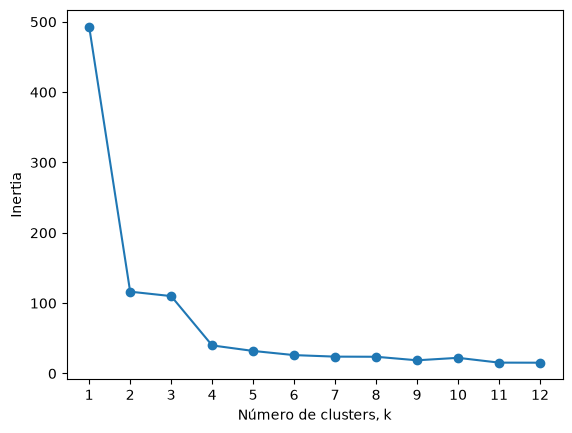

In [66]:
plt.plot(list(inertias.keys()),
         list(inertias.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Inertia')
plt.xticks(list(inertias.keys()))
plt.show()

A medida que aumentamos k, la inercia cae muy rápid. Esta curva tiene aproximadamente la forma de un brazo, y hay un "codo" en k = 3.

__SI NO TUVIERAMOS MAS CONOCIMIENTO DE LOS DATOS k = 3 SERíA UNA BUENA OPCIÓN__

* Cualquier valor antes del codo sería dramático
* Cualquier valor despues del codo no ayudaría mucho, ya que podríamos simplemente estar dividiendo grupos perfectamente buenos por la mitad sin una buena razón.

Entonces, __si no hay información que ayude a tomar una mejor decisión, el valor del codo es la mejor opción__.

__NOTA__: En general este proceso no es sencillo y hay que tener en cuenta que K-Means es muy sensible a diferencias en las varianzas de las variables y a variables con escalas muy distintas.

#### Silhouette

* Un enfoque más preciso (pero también computacionalmente más costoso) es utilizar el __Silhouette score__.

* El __Silhouette score__ es el silhouette medio sobre todas las instancias.

* El Silhouette de una instancia se define cómo $\frac{b-a}{max(a, b)}$ dónde:
    * $a$ es la distancia media a otras instancias en el mismo cluster (la distancia intra cluster media)
    * $b$ es la media de la distancia al cluster mas cercano (la distancia media a las instancias del siguiente cluster, definida como la que minimiza a $b$, excluyendo la distancia del propio cluster)

* El coeficiente Silouette está entre -1 y 1 esto se interpreta:
    * Entre mas cerca está de 1, significa que la instancia está bien dentro de su cluster y lejos de otros clusters
    * Entre mas cerca está de 0, significa que está muy cerca de una frontera entre clusters
    * Entre mas cerca está de -1 significa que la instancia ha sido asignada a un cluster donde no corresponde

##### Silhouette scores

In [67]:
from sklearn.metrics import silhouette_score

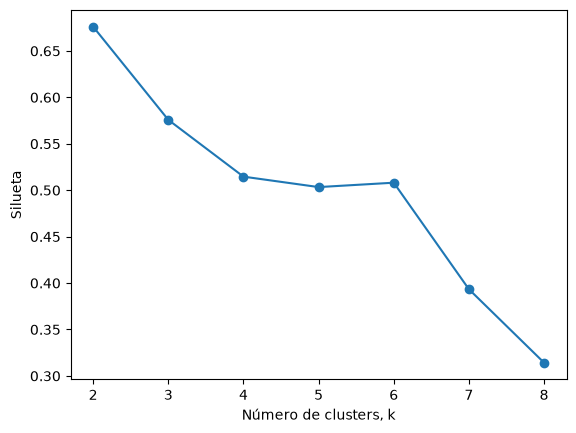

In [68]:
silhouettes = {k: silhouette_score(X_train, KMeans(n_clusters=k).fit_predict(X_train)) for k in range(2, 9)}

plt.plot(list(silhouettes.keys()),
         list(silhouettes.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Silueta')
plt.xticks(list(silhouettes.keys()))
plt.show()

Está visualización es mas informativa que la gráfica del codo, en esta visualización observamos que `k=2` es un excelente `k`, pero `k=3` también es una excelente opción, estas opciones son mucho mejores que el resto, esta gráfica puede llegar a ser mas informativa que solo comparar inercias.

##### Silhouette diagrama

Una visualización aun mas informativa se obtiene cuando gráficamos el silhouette de cada instancia, agrupada por los clusters que los contiene y ordenada por sus valores.

Cada diagrama tiene forma de cuchillo por cluster:
* La altura del cuchillo significa la cantidad de instancias que contiene el cluster
* El ancho representa los coeficientes silhouette ordenados en el cluster (entre mas ancho mejor)
* La linea punteada representa el coeficiente silhouette medio

For n_clusters = 2, the average silhouette_score is: 0.6761
For n_clusters = 3, the average silhouette_score is: 0.5758
For n_clusters = 4, the average silhouette_score is: 0.5146
For n_clusters = 5, the average silhouette_score is: 0.4089
For n_clusters = 6, the average silhouette_score is: 0.3977
For n_clusters = 7, the average silhouette_score is: 0.3980
For n_clusters = 8, the average silhouette_score is: 0.3463


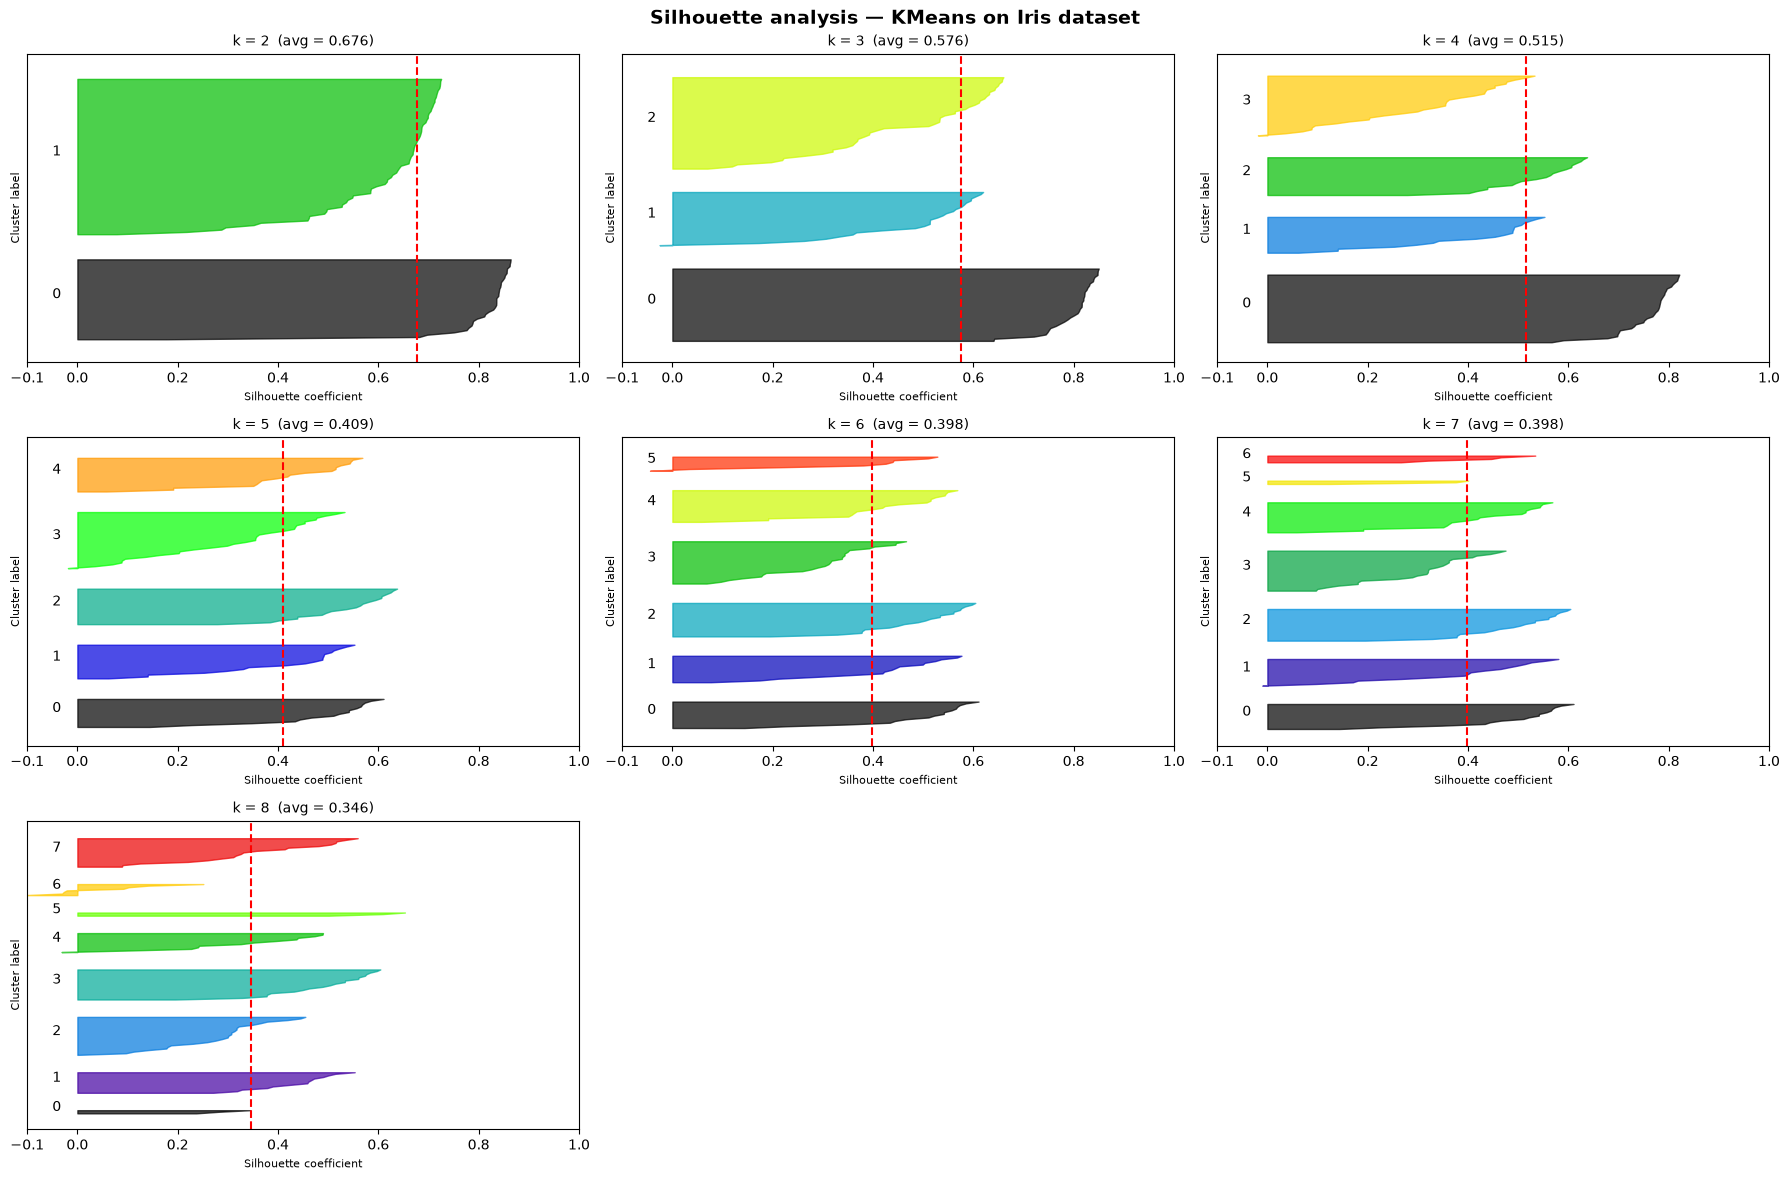

In [69]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

n_clusters_range = range(2, 9)
n_plots = len(n_clusters_range)
cols = 3
rows = (n_plots + cols - 1) // cols  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for idx, k in enumerate(n_clusters_range):
    ax = axes[idx]

    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_train) + (k + 1) * 10])

    clusterer = KMeans(n_clusters=k, random_state=10, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_train)

    silhouette_avg = silhouette_score(X_train, cluster_labels)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_train, cluster_labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"k = {k}  (avg = {silhouette_avg:.3f})", fontsize=10)
    ax.set_xlabel("Silhouette coefficient", fontsize=8)
    ax.set_ylabel("Cluster label", fontsize=8)
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# Ocultar subplots sobrantes (si el total no es múltiplo de cols)
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Silhouette analysis — KMeans on Iris dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### Recomendaciones para K-means

* Normalizar las variables antes de hacer K-means, restar a cada variable su media y dividirla por la desviación típica

## Challenge

Considera los datos `creditcard.csv`. Lo puedes cargar directamente desde Kaggle con `kagglehub`.

Como contexto, estos datos fueron obtenidos del siguiente enlace: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Consejo: Lee atentamente la descripción del dataset y el significado de las columnas en el enlace anterior.


## Realiza lo siguiente
1. Entrena un modelo con KMeans, recuerda separar la columna objetivo `Class` del resto de las columnas.
2. Identifica la mejor K utilizando el método del codo y el método de las siluetas.
3. Añade una columna llamada `cluster` etiquetando el set de prueba (30% de los datos).
4. Identifica el grupo al que pertenecen los datos cuyo `Class` es igual a 1. ¿Pertenecen a un solo grupo o a varios?


### 1. Cargar los datos en local

Para este challenge usaré el archivo local `creditcard.csv` dentro del directorio `data`.


In [70]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

candidate_paths = [
    Path("data/creditcard.csv"),
    Path("4 Introducción al Aprendizaje Automático/data/creditcard.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("No se encontró creditcard.csv en el directorio data")

df = pd.read_csv(data_path)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 2. Separar variable objetivo y crear entrenamiento/prueba

Separaré la columna `Class` del resto de variables y usaré un split 70/30.


In [71]:
X = df.drop(columns="Class")
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((199364, 30), (85443, 30))

### 3. Escalar las variables

Como vimos antes en el notebook, K-Means es sensible a la escala de las variables, así que normalizaré los datos antes de entrenar.


In [72]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Buscar una buena K

Para mantener el análisis ágil, evaluaré el método del codo y las siluetas sobre una muestra de `10,000` observaciones del set de entrenamiento. Después entrenaré el modelo final con todo `X_train`.


In [73]:
evaluation_sample_size = 10_000
X_train_sample = pd.DataFrame(X_train_scaled).sample(
    n=evaluation_sample_size, random_state=42
)

k_values = list(range(2, 9))
inertias = []
silhouettes = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_train_sample)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_train_sample, labels))

results_df = pd.DataFrame({
    "k": k_values,
    "inertia": inertias,
    "silhouette": silhouettes,
})
results_df

,k,inertia,silhouette
0,2,287926.969481,0.067921
1,3,275030.599288,0.068751
2,4,266149.006219,0.067939
3,5,258792.978808,0.078959
4,6,252949.731623,0.080375
5,7,246601.546903,0.074043
6,8,237651.101383,0.083163


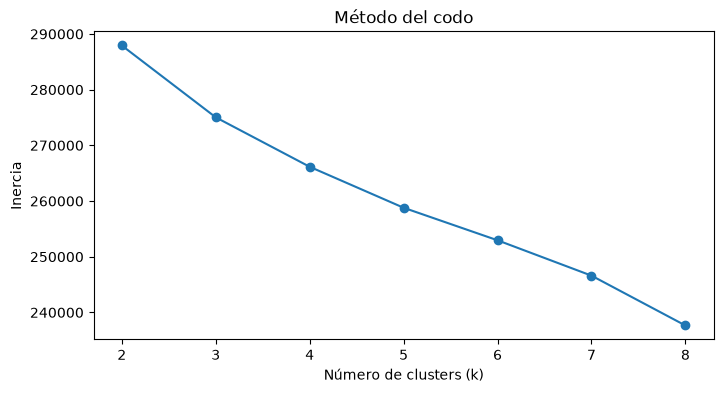

In [74]:
plt.figure(figsize=(8, 4))
plt.plot(results_df["k"], results_df["inertia"], marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(results_df["k"])
plt.show()

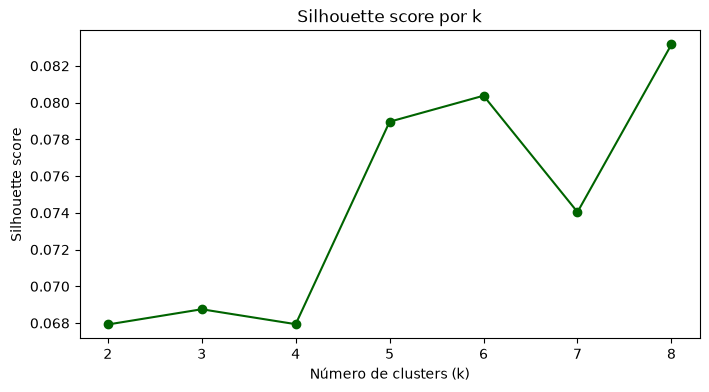

In [75]:
plt.figure(figsize=(8, 4))
plt.plot(results_df["k"], results_df["silhouette"], marker="o", color="darkgreen")
plt.title("Silhouette score por k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(results_df["k"])
plt.show()

### 5. Elegir K y entrenar el modelo final

La curva del codo no muestra un quiebre extremadamente fuerte, pero sí una caída sostenida. Por otro lado, el mayor `silhouette score` dentro del rango probado aparece en `k = 8`, así que usaré ese valor para el modelo final.


In [76]:
best_k = int(results_df.loc[results_df["silhouette"].idxmax(), "k"])
best_k

8

In [77]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_kmeans.fit(X_train_scaled)

,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](8, 30)","[[-0

### 6. Etiquetar el set de prueba con la columna `cluster`

Ahora asignaré a cada observación del set de prueba el cluster predicho por el modelo entrenado.


In [78]:
test_results = X_test.copy()
test_results["Class"] = y_test.values
test_results["cluster"] = final_kmeans.predict(X_test_scaled)
test_results.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,cluster
186882,127294.0,-2.537331,1.890864,-0.840555,-1.102759,-2.105725,0.367811,-2.737844,-3.543314,-0.483147,...,-2.167329,1.022567,-0.241143,-1.094885,-0.475427,-0.177157,-0.082691,37.40,0,5
165754,117632.0,-0.250839,1.104108,0.206089,0.417324,1.204079,-0.350694,1.369769,-0.133535,-0.957100,...,0.499501,-0.392572,-0.393364,0.233354,-0.490717,0.143897,0.136810,9.27,0,2
235285,148330.0,0.568980,-2.520416,-1.114138,1.670652,-1.128945,0.398822,0.190403,0.161493,0.840595,...,-0.760732,-0.181332,0.595866,-0.760920,-1.048927,-0.096970,0.088686,700.00,0,1
101271,67778.0,1.328892,0.226908,-0.308968,0.381772,0.238490,-0.282946,0.029460,-0.079962,0.227173,...,-1.148959,-0.047403,-1.074464,0.375683,0.182045,-0.031732,0.017501,14.99,0,0
5832,6308.0,1.124863,-0.165691,1.337053,1.030033,-0.891116,0.202926,-0.825094,0.163280,2.301808,...,-0.195607,0.072785,0.045625,0.135192,0.308617,0.001142,0.017673,17.25,0,0


### 7. Revisar en qué grupos caen los fraudes

La pregunta clave es si las observaciones con `Class = 1` quedan concentradas en un único grupo o repartidas en varios.


In [79]:
fraud_cluster_counts = (
    test_results.loc[test_results["Class"] == 1, "cluster"]
    .value_counts()
    .sort_index()
)

fraud_cluster_counts

cluster
0    30
1    29
2    10
3     2
5     2
6    75
Name: count, dtype: int64

In [80]:
test_results["cluster"].value_counts().sort_index()

cluster
0    34720
1    15749
2    17086
3     1153
4     5111
5    10563
6       90
7      971
Name: count, dtype: int64

### 8. Conclusión del challenge

Entrené un modelo de `KMeans` separando correctamente la variable objetivo `Class`.
Para elegir `k`, usé el método del codo y el `silhouette score` sobre una muestra del set de entrenamiento.
El mejor valor de `k` en el rango evaluado fue `8`, ya que obtuvo el mayor `silhouette score`.
Añadí la columna `cluster` al set de prueba.

En particular, los fraudes del set de prueba quedaron repartidos en `6` clusters distintos, con mayor concentración en el cluster `6`, pero también con presencia en los clusters `0`, `1`, `2`, `3` y `5`. Esto sugiere que el comportamiento fraudulento no forma un único patrón compacto bajo K-Means.
